# Введение в нейронные сети
## Классификация MNIST

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from tqdm import tqdm

### Подготовка данных для использования
 - Получение Датасета
 - Получение Даталоадера
 - Просмотр данных

In [2]:
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=ToTensor())
test_dataset = datasets.MNIST(root="./data", train=False, transform=ToTensor())

In [3]:
BATCH_SIZE = 64

In [4]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=4)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=4)

In [5]:
### Целевое значение
next(iter(train_dataloader))[1]

tensor([7, 0, 8, 8, 7, 5, 3, 6, 1, 8, 0, 6, 5, 3, 1, 3, 5, 7, 0, 8, 1, 1, 0, 7,
        7, 0, 4, 8, 1, 1, 3, 7, 9, 6, 9, 1, 7, 4, 1, 1, 2, 0, 3, 8, 9, 8, 4, 8,
        5, 0, 3, 6, 1, 2, 7, 1, 8, 2, 0, 6, 3, 4, 5, 1])

In [6]:
### Torch tensor
next(iter(train_dataloader))[0].shape

torch.Size([64, 1, 28, 28])

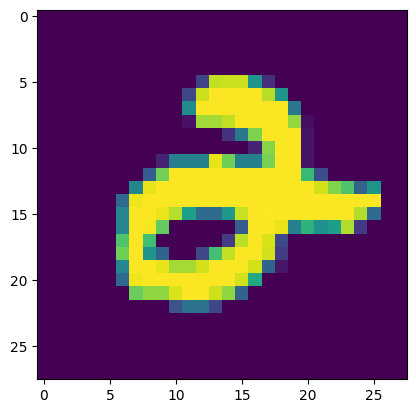

In [7]:
for_show = next(iter(train_dataloader))[0]
plt.imshow(for_show.numpy()[0][0])

### Построим нейронную сеть

In [8]:
class MyNN(torch.nn.Module):
    def __init__(self, dims=[256, 64, 32], dropout_p=0):
        super().__init__()
        self.Linear1 = torch.nn.Linear(28 * 28, dims[0])
        self.Linear2 = torch.nn.Linear(dims[0], dims[1])
        self.Linear3 = torch.nn.Linear(dims[1], dims[2])
        self.Linear4 = torch.nn.Linear(dims[2], 10)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(dropout_p)
        self.SoftMax = torch.nn.Softmax(dim=1)

    def forward(self, x):
        x = x.squeeze(1)
        x = x.flatten(1)
        x = self.dropout(x)
        x = self.Linear1(x)
        x = self.relu(x)
        x = self.Linear2(x)
        x = self.relu(x)
        x = self.Linear3(x)
        x = self.relu(x)
        x = self.Linear4(x)
        x = self.SoftMax(x)
        return x

In [9]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [10]:
model = MyNN().to(DEVICE)

### Функция, вычисляющая лосс

In [11]:
def loss_function(true, pred):
    loss = torch.nn.CrossEntropyLoss()
    return loss(pred, true)

### Оптимизатор

In [12]:
optimizer = torch.optim.SGD(params=model.parameters(), lr=1e-3)

### Построим процесс обучения нейронной сети

In [13]:
NUM_EPOCHS = 250

In [14]:
train_loss = []
test_loss = []
for epoch in tqdm(range(NUM_EPOCHS)):
    model.train(True)
    train_loss_epoch = 0
    test_loss_epoch = 0
    for X, y in train_dataloader:
        true = y.to(DEVICE)
        X = X.to(DEVICE)
        model.zero_grad()
        predictions = model.forward(X)
        loss_value = loss_function(true, predictions)
        loss_value.backward()
        train_loss_epoch += loss_value.item() / len(train_dataloader)
        optimizer.step()
    train_loss.append(train_loss_epoch)
    model.train(False)
    for X, y in test_dataloader:
        true = y.to(DEVICE)
        X = X.to(DEVICE)
        with torch.no_grad():
            predictions = model.forward(X)
            loss_value = loss_function(true, predictions)
        test_loss_epoch += loss_value.item() / len(test_dataloader)
    test_loss.append(test_loss_epoch)
    # print(epoch, train_loss[-1], test_loss[-1])

100%|███████████████████████████████████████████████████| 250/250 [06:59<00:00,  1.68s/it]


In [15]:
model(X).shape

torch.Size([64, 10])

<Axes: >

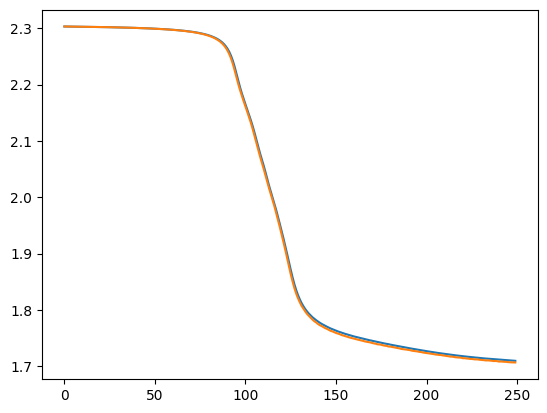

In [16]:
sns.lineplot(train_loss)
sns.lineplot(test_loss)

In [17]:
preds = []
reals = []
for X, y in test_dataloader:
    preds.append(model(X.to(DEVICE)).cpu().detach().numpy())
    reals.append(y.numpy())

In [18]:
preds = (np.concatenate(preds).argmax(axis=1)).astype(int)

In [19]:
reals = np.concatenate(reals)

In [20]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [21]:
print(classification_report(reals, preds))

              precision    recall  f1-score   support

           0       0.84      0.98      0.90       979
           1       0.94      0.99      0.96      1132
           2       0.73      0.90      0.81      1031
           3       0.57      0.94      0.71      1008
           4       0.82      0.93      0.87       980
           5       0.00      0.00      0.00       891
           6       0.77      0.96      0.85       956
           7       0.86      0.90      0.88      1026
           8       0.00      0.00      0.00       974
           9       0.65      0.88      0.75      1007

    accuracy                           0.76      9984
   macro avg       0.62      0.75      0.67      9984
weighted avg       0.63      0.76      0.69      9984



/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [22]:
model2 = MyNN(dropout_p=0.3).to(DEVICE)
optimizer2 = torch.optim.SGD(params=model2.parameters(), lr=1e-3)
train_loss = []
test_loss = []
for epoch in tqdm(range(NUM_EPOCHS)):
    model2.train(True)
    train_loss_epoch = 0
    test_loss_epoch = 0
    for X, y in train_dataloader:
        true = y.to(DEVICE)
        X = X.to(DEVICE)
        model2.zero_grad()
        predictions = model2.forward(X)
        loss_value = loss_function(true, predictions)
        loss_value.backward()
        train_loss_epoch += loss_value.item() / len(train_dataloader)
        optimizer2.step()
    train_loss.append(train_loss_epoch)
    model2.train(False)
    for X, y in test_dataloader:
        true = y.to(DEVICE)
        X = X.to(DEVICE)
        with torch.no_grad():
            predictions = model2.forward(X)
            loss_value = loss_function(true, predictions)
        test_loss_epoch += loss_value.item() / len(test_dataloader)
    test_loss.append(test_loss_epoch)
    # print(epoch, train_loss[-1], test_loss[-1])

preds = []
reals = []
for X, y in test_dataloader:
    preds.append(model2(X.to(DEVICE)).cpu().detach().numpy())
    reals.append(y.numpy())
preds = (np.concatenate(preds).argmax(axis=1)).astype(int)
reals = np.concatenate(reals)
print(classification_report(reals, preds))

100%|███████████████████████████████████████████████████| 250/250 [07:11<00:00,  1.73s/it]


              precision    recall  f1-score   support

           0       0.84      0.98      0.90       978
           1       0.91      0.97      0.94      1135
           2       0.00      0.00      0.00      1031
           3       0.52      0.90      0.66      1009
           4       0.83      0.93      0.88       977
           5       0.00      0.00      0.00       890
           6       0.74      0.95      0.83       958
           7       0.89      0.86      0.87      1027
           8       0.56      0.87      0.68       973
           9       0.81      0.87      0.84      1006

    accuracy                           0.74      9984
   macro avg       0.61      0.73      0.66      9984
weighted avg       0.62      0.74      0.67      9984



/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vvh413/dev/hse/dsml2025/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri